In [5]:
## basic librarires
from glob import glob
import numpy as np

## for reading ROOT files and the analysis
import uproot
import awkward as ak
import vector
vector.register_awkward()

## for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib inline

# HEP-stype plots
import mplhep as hep 
hep.style.use("CMS")
plt.rcParams['figure.figsize'] = (8,6) 

In [6]:
%%time

#f = uproot.open("../../../../HTo2LongLivedTo4mu_MH-125_MFF-12_CTau-10000mm_TuneCP5_14TeV-pythia8_dec18.root")
f = uproot.open("../../../../HTo2LongLivedTo4mu_MH-125_MFF-12_CTau-900mm_TuneCP5_14TeV-pythia8_L1NanoWithGenPropagated_20260212.root")
events = f["Events"].arrays(library="ak")
f["Events"].show(filter_name = "stub_*") 
f["Events"].show(filter_name = "GenPart*") 

branches =["/(stub)_(eta1|eta2|phi1|phi2|qual|depthregion|etaregion|phiregion|type|tfLayer|id|etaqual|offeta1|offeta2|offphi1|offphi2|isBarrel|isEndcap)/"]
branches +=["/(GenPart)_(pt|eta|phi|mass|pdgId|dXY|lXY|vertX|vertY|vertZ|status|statusFlags|etaSt2|phiSt2|etaSt1|phiSt1)/"]

data_events = f["Events"].arrays(filter_name = branches,how = "zip") 

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
stub_isBarrel        | bool[]                   | AsJagged(AsDtype('bool'))
stub_isEndcap        | bool[]                   | AsJagged(AsDtype('bool'))
stub_depthregion     | int16_t[]                | AsJagged(AsDtype('>i2'))
stub_etaregion       | int16_t[]                | AsJagged(AsDtype('>i2'))
stub_phiregion       | int16_t[]                | AsJagged(AsDtype('>i2'))
stub_tfLayer         | uint16_t[]               | AsJagged(AsDtype('>u2'))
stub_addr            | int32_t[]                | AsJagged(AsDtype('>i4'))
stub_bx              | int32_t[]                | AsJagged(AsDtype('>i4'))
stub_eta1            | int32_t[]                | AsJagged(AsDtype('>i4'))
stub_eta2            | int32_t[]                | AsJagged(AsDtype('>i4'))
stub_etaqual         | int32_t[]                | AsJagged(AsDtype('>i4'))
stub_id    

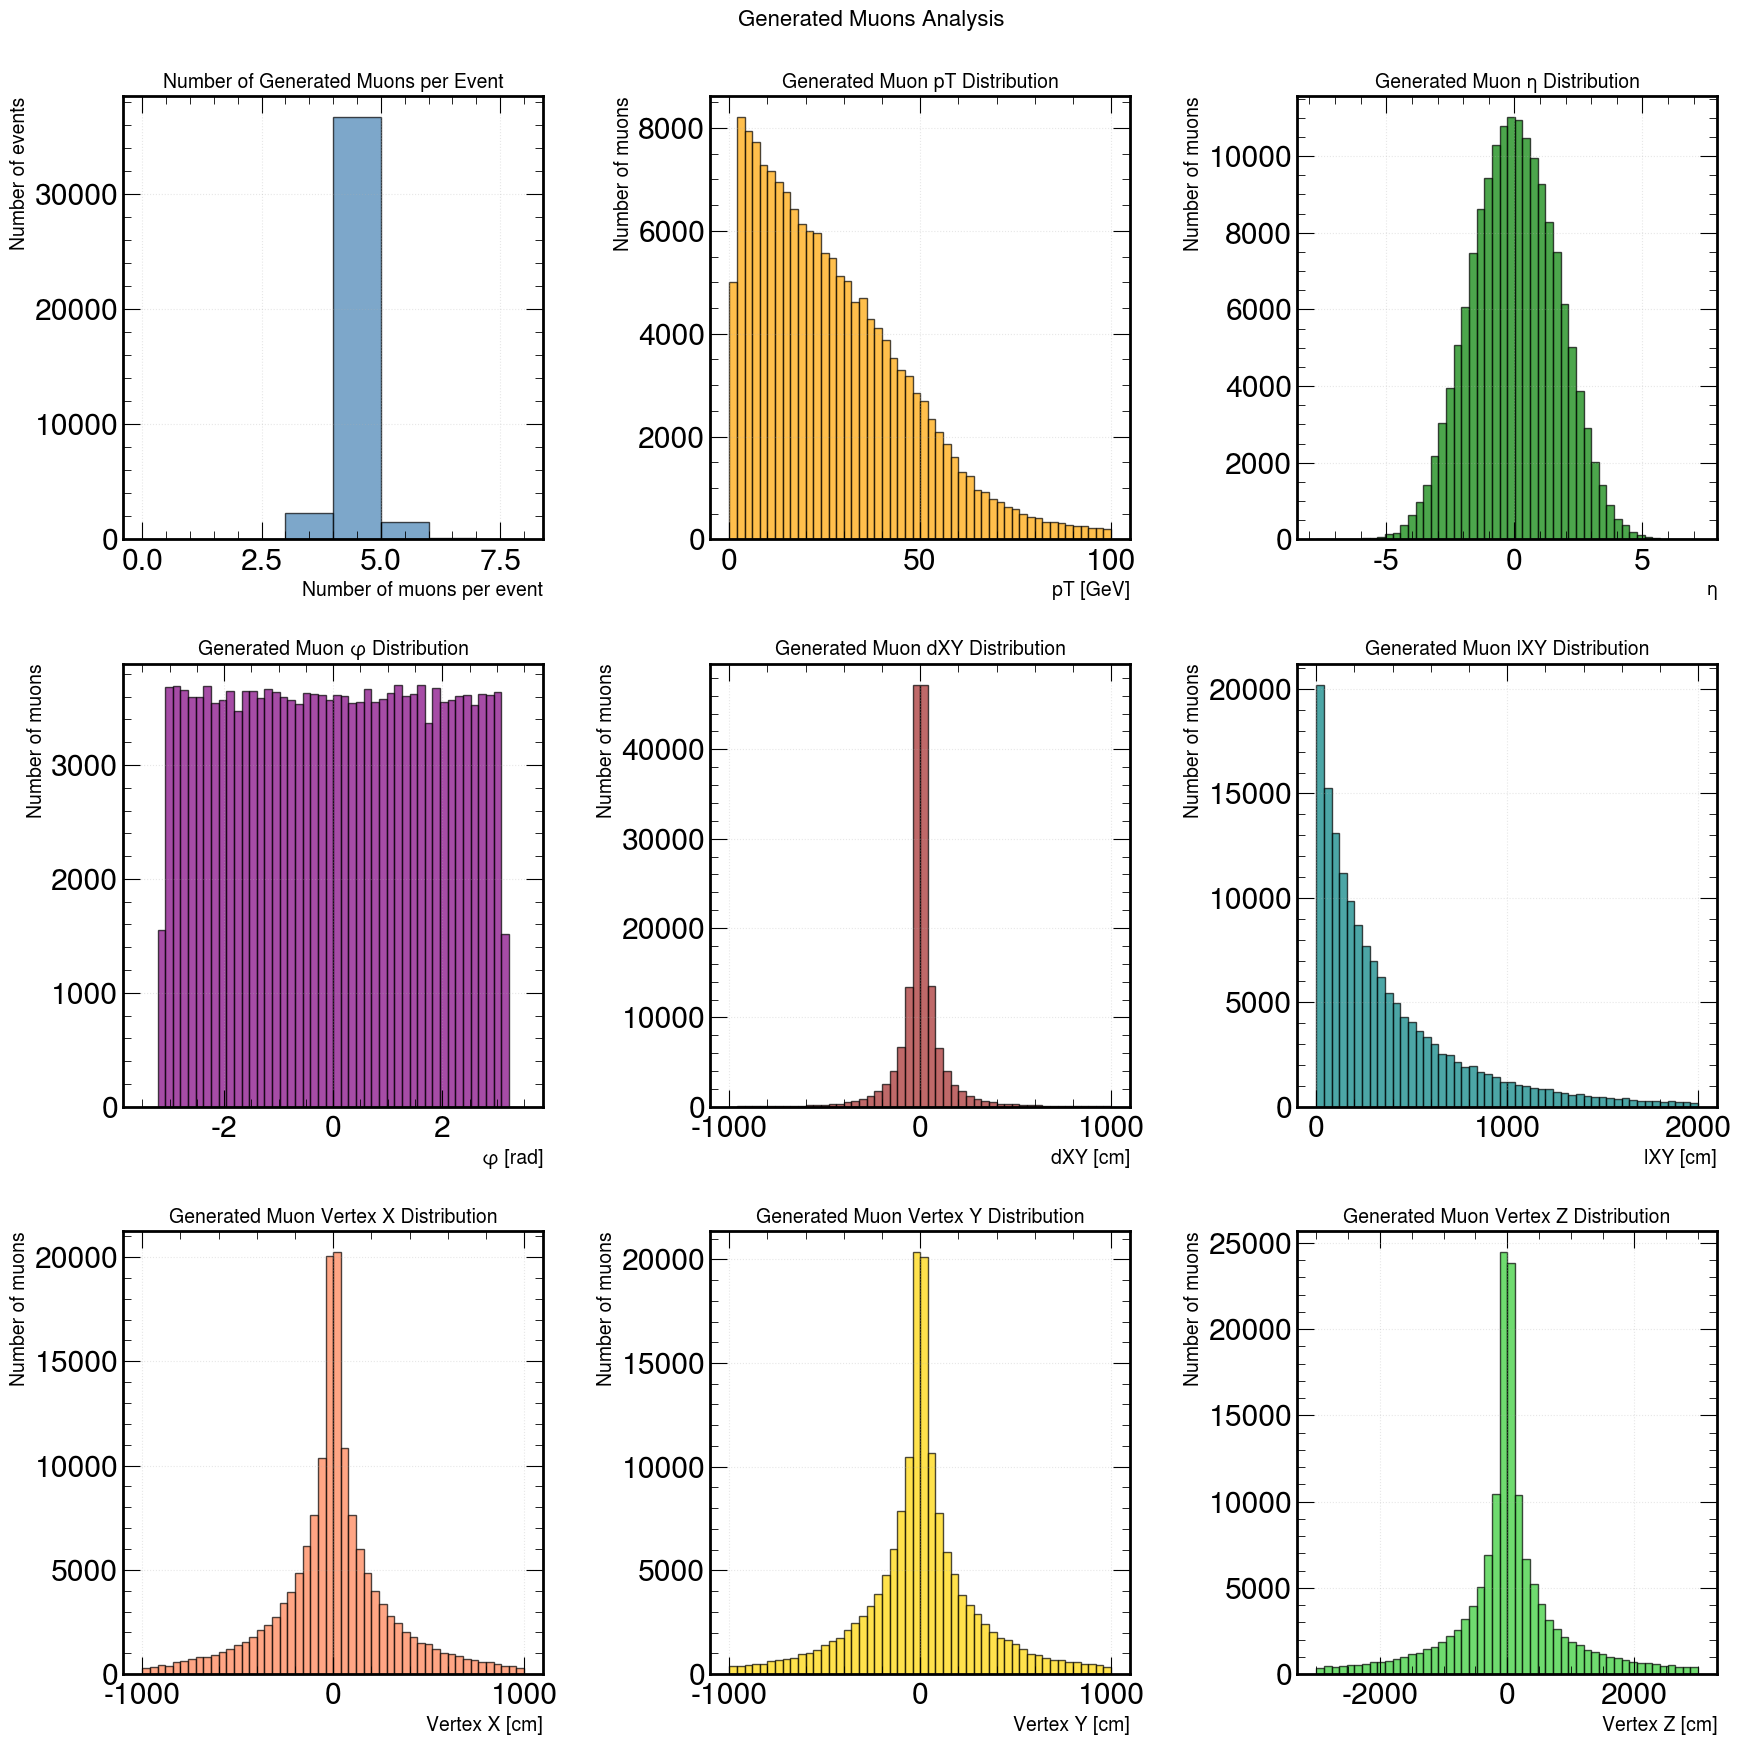


=== Generated Muons Statistics ===
Total events: 40578
Events with muons: 40578 (100.00%)
Total muons: 161755
Average muons per event: 3.99

Muon pT: min=1.00 GeV, max=1216.00 GeV, mean=29.35 GeV
Muon η: min=-7.73, max=7.17, mean=-0.00
Muon φ: min=-3.14 rad, max=3.14 rad, mean=-0.01 rad
Muon dXY: min=-3178.789 cm, max=3741.742 cm, mean=0.205 cm
Muon lXY: min=0.000 cm, max=15585.383 cm, mean=432.501 cm


In [7]:
mask_allmuons = (abs(data_events.GenPart.pdgId) == 13) & \
                ((data_events.GenPart.statusFlags & (1 << 13)) != 0) & \
                (data_events.GenPart.pt > 1)

# Muons per event
n_muons_per_event = ak.num(data_events.GenPart.pdgId[mask_allmuons])

# Kinematics
muon_pt = ak.flatten(data_events.GenPart.pt[mask_allmuons])
muon_eta = ak.flatten(data_events.GenPart.eta[mask_allmuons])
muon_phi = ak.flatten(data_events.GenPart.phi[mask_allmuons])

# Displacement variables
muon_dxy = ak.flatten(data_events.GenPart.dXY[mask_allmuons])
muon_lxy = ak.flatten(data_events.GenPart.lXY[mask_allmuons])

# Plots
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle('Generated Muons Analysis', fontsize=16)

axes = axes.flatten()

# Plot 1: Number of muons per event
axes[0].hist(ak.to_numpy(n_muons_per_event),
             bins=range(0, max(ak.to_numpy(n_muons_per_event)) + 2),
             alpha=0.7, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Number of muons per event', fontsize=14)
axes[0].set_ylabel('Number of events', fontsize=14)
axes[0].set_title('Number of Generated Muons per Event',fontsize=14)
axes[0].grid(True, alpha=0.3)

# Plot 2: Muon pT distribution
axes[1].hist(ak.to_numpy(muon_pt), bins=50, range=(0, 100),
             alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('pT [GeV]', fontsize=14)
axes[1].set_ylabel('Number of muons', fontsize=14)
axes[1].set_title('Generated Muon pT Distribution', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Plot 3: Muon eta distribution
axes[2].hist(ak.to_numpy(muon_eta), bins=50,              alpha=0.7, edgecolor='black', color='green')
axes[2].set_xlabel('η', fontsize=14)
axes[2].set_ylabel('Number of muons', fontsize=14)
axes[2].set_title('Generated Muon η Distribution', fontsize=14)
axes[2].grid(True, alpha=0.3)

# Plot 4: Muon phi distribution
axes[3].hist(ak.to_numpy(muon_phi), bins=50, range=(-3.5, 3.5),
             alpha=0.7, edgecolor='black', color='purple')
axes[3].set_xlabel('φ [rad]', fontsize=14)
axes[3].set_ylabel('Number of muons', fontsize=14)
axes[3].set_title('Generated Muon φ Distribution', fontsize=14)
axes[3].grid(True, alpha=0.3)

# Plot 5: Muon dXY distribution
axes[4].hist(ak.to_numpy(muon_dxy), bins=50, range=(-1000, 1000),
             alpha=0.7, edgecolor='black', color='brown')
axes[4].set_xlabel('dXY [cm]', fontsize=14)
axes[4].set_ylabel('Number of muons', fontsize=14)
axes[4].set_title('Generated Muon dXY Distribution', fontsize=14)
axes[4].grid(True, alpha=0.3)

# Plot 6: Muon lXY distribution
axes[5].hist(ak.to_numpy(muon_lxy), bins=50, range=(0, 2000),
             alpha=0.7, edgecolor='black', color='teal')
axes[5].set_xlabel('lXY [cm]', fontsize=14)
axes[5].set_ylabel('Number of muons', fontsize=14)
axes[5].set_title('Generated Muon lXY Distribution', fontsize=14)
axes[5].grid(True, alpha=0.3)

# Plot 7: Muon vx
axes[6].hist(ak.to_numpy(ak.flatten(data_events.GenPart.vertX[mask_allmuons])), bins=50, range=(-1000, 1000),
             alpha=0.7,
                edgecolor='black', color='coral')
axes[6].set_xlabel('Vertex X [cm]', fontsize=14)
axes[6].set_ylabel('Number of muons', fontsize=14)
axes[6].set_title('Generated Muon Vertex X Distribution', fontsize=14)
axes[6].grid(True, alpha=0.3)
# Plot 8: Muon vy
axes[7].hist(ak.to_numpy(ak.flatten(data_events.GenPart.vertY[mask_allmuons])), bins=50, range=(-1000, 1000), 
                alpha=0.7, edgecolor='black', color='gold')
axes[7].set_xlabel('Vertex Y [cm]', fontsize=14)
axes[7].set_ylabel('Number of muons', fontsize=14)
axes[7].set_title('Generated Muon Vertex Y Distribution', fontsize=14)
axes[7].grid(True, alpha=0.3)

# Plot 9: Muon vz
axes[8].hist(ak.to_numpy(ak.flatten(data_events.GenPart.vertZ[mask_allmuons])), bins=50, range=(-3000, 3000),
                alpha=0.7, edgecolor='black', color='limegreen')
axes[8].set_xlabel('Vertex Z [cm]', fontsize=14)
axes[8].set_ylabel('Number of muons', fontsize=14)
axes[8].set_title('Generated Muon Vertex Z Distribution', fontsize=14)
axes[8].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Print statistics
print(f"\n=== Generated Muons Statistics ===")
print(f"Total events: {len(n_muons_per_event)}")
print(f"Events with muons: {ak.sum(n_muons_per_event > 0)} ({100*ak.sum(n_muons_per_event > 0)/len(n_muons_per_event):.2f}%)")
print(f"Total muons: {len(muon_pt)}")
print(f"Average muons per event: {ak.mean(n_muons_per_event):.2f}")
print(f"\nMuon pT: min={ak.min(muon_pt):.2f} GeV, max={ak.max(muon_pt):.2f} GeV, mean={ak.mean(muon_pt):.2f} GeV")
print(f"Muon η: min={ak.min(muon_eta):.2f}, max={ak.max(muon_eta):.2f}, mean={ak.mean(muon_eta):.2f}")
print(f"Muon φ: min={ak.min(muon_phi):.2f} rad, max={ak.max(muon_phi):.2f} rad, mean={ak.mean(muon_phi):.2f} rad")
print(f"Muon dXY: min={ak.min(muon_dxy):.3f} cm, max={ak.max(muon_dxy):.3f} cm, mean={ak.mean(muon_dxy):.3f} cm")
print(f"Muon lXY: min={ak.min(muon_lxy):.3f} cm, max={ak.max(muon_lxy):.3f} cm, mean={ak.mean(muon_lxy):.3f} cm")



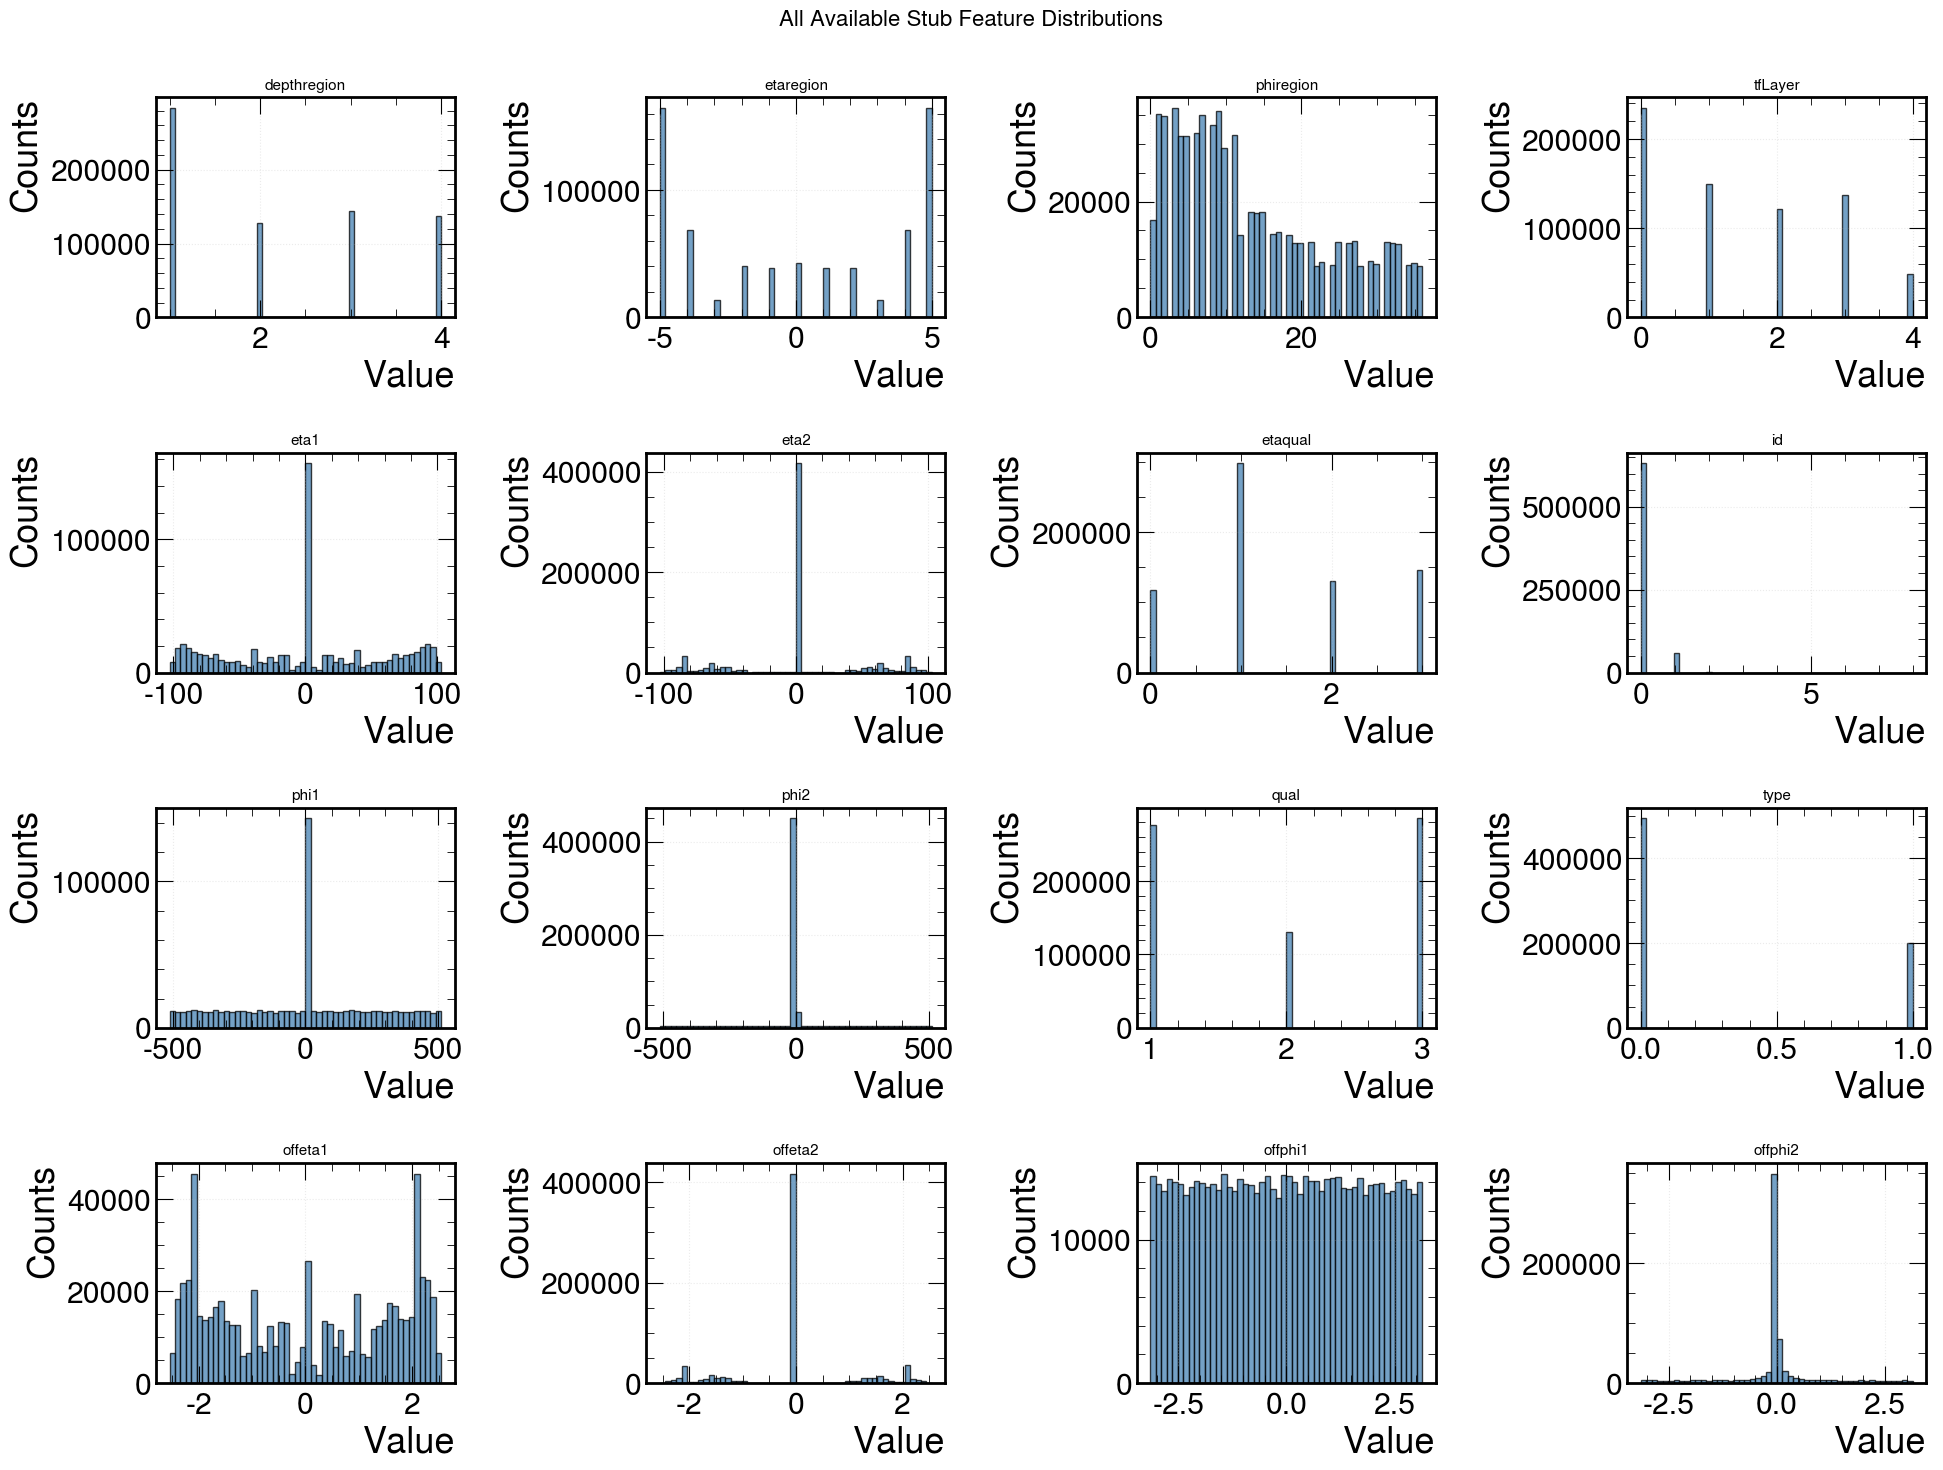

Plotted 16 stub features.


In [8]:
# Plot all available stub features in data_events.stub
stub_fields = ak.fields(data_events.stub)

# Keep only numeric features that can be flattened and plotted
plot_features = []
feature_arrays = {}

for feat in stub_fields:
    try:
        arr = ak.to_numpy(ak.flatten(data_events.stub[feat], axis=None))
        if np.issubdtype(arr.dtype, np.number) and arr.size > 0:
            arr = arr[np.isfinite(arr)]  # remove NaN/inf
            if arr.size > 0:
                plot_features.append(feat)
                feature_arrays[feat] = arr
    except Exception:
        pass

n_feat = len(plot_features)
if n_feat == 0:
    print("No plottable numeric stub features found.")
else:
    ncols = 4
    nrows = int(np.ceil(n_feat / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, feat in enumerate(plot_features):
        ax = axes[i]
        vals = feature_arrays[feat]
        ax.hist(vals, bins=50, alpha=0.75, edgecolor="black", color="steelblue")
        ax.set_title(feat, fontsize=11)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")
        ax.grid(True, alpha=0.25)

    # Hide unused axes
    for j in range(n_feat, len(axes)):
        axes[j].axis("off")

    fig.suptitle("All Available Stub Feature Distributions", fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"Plotted {n_feat} stub features.")

RPC-only stubs (qual==2): 130741 / 692436 (18.88%)


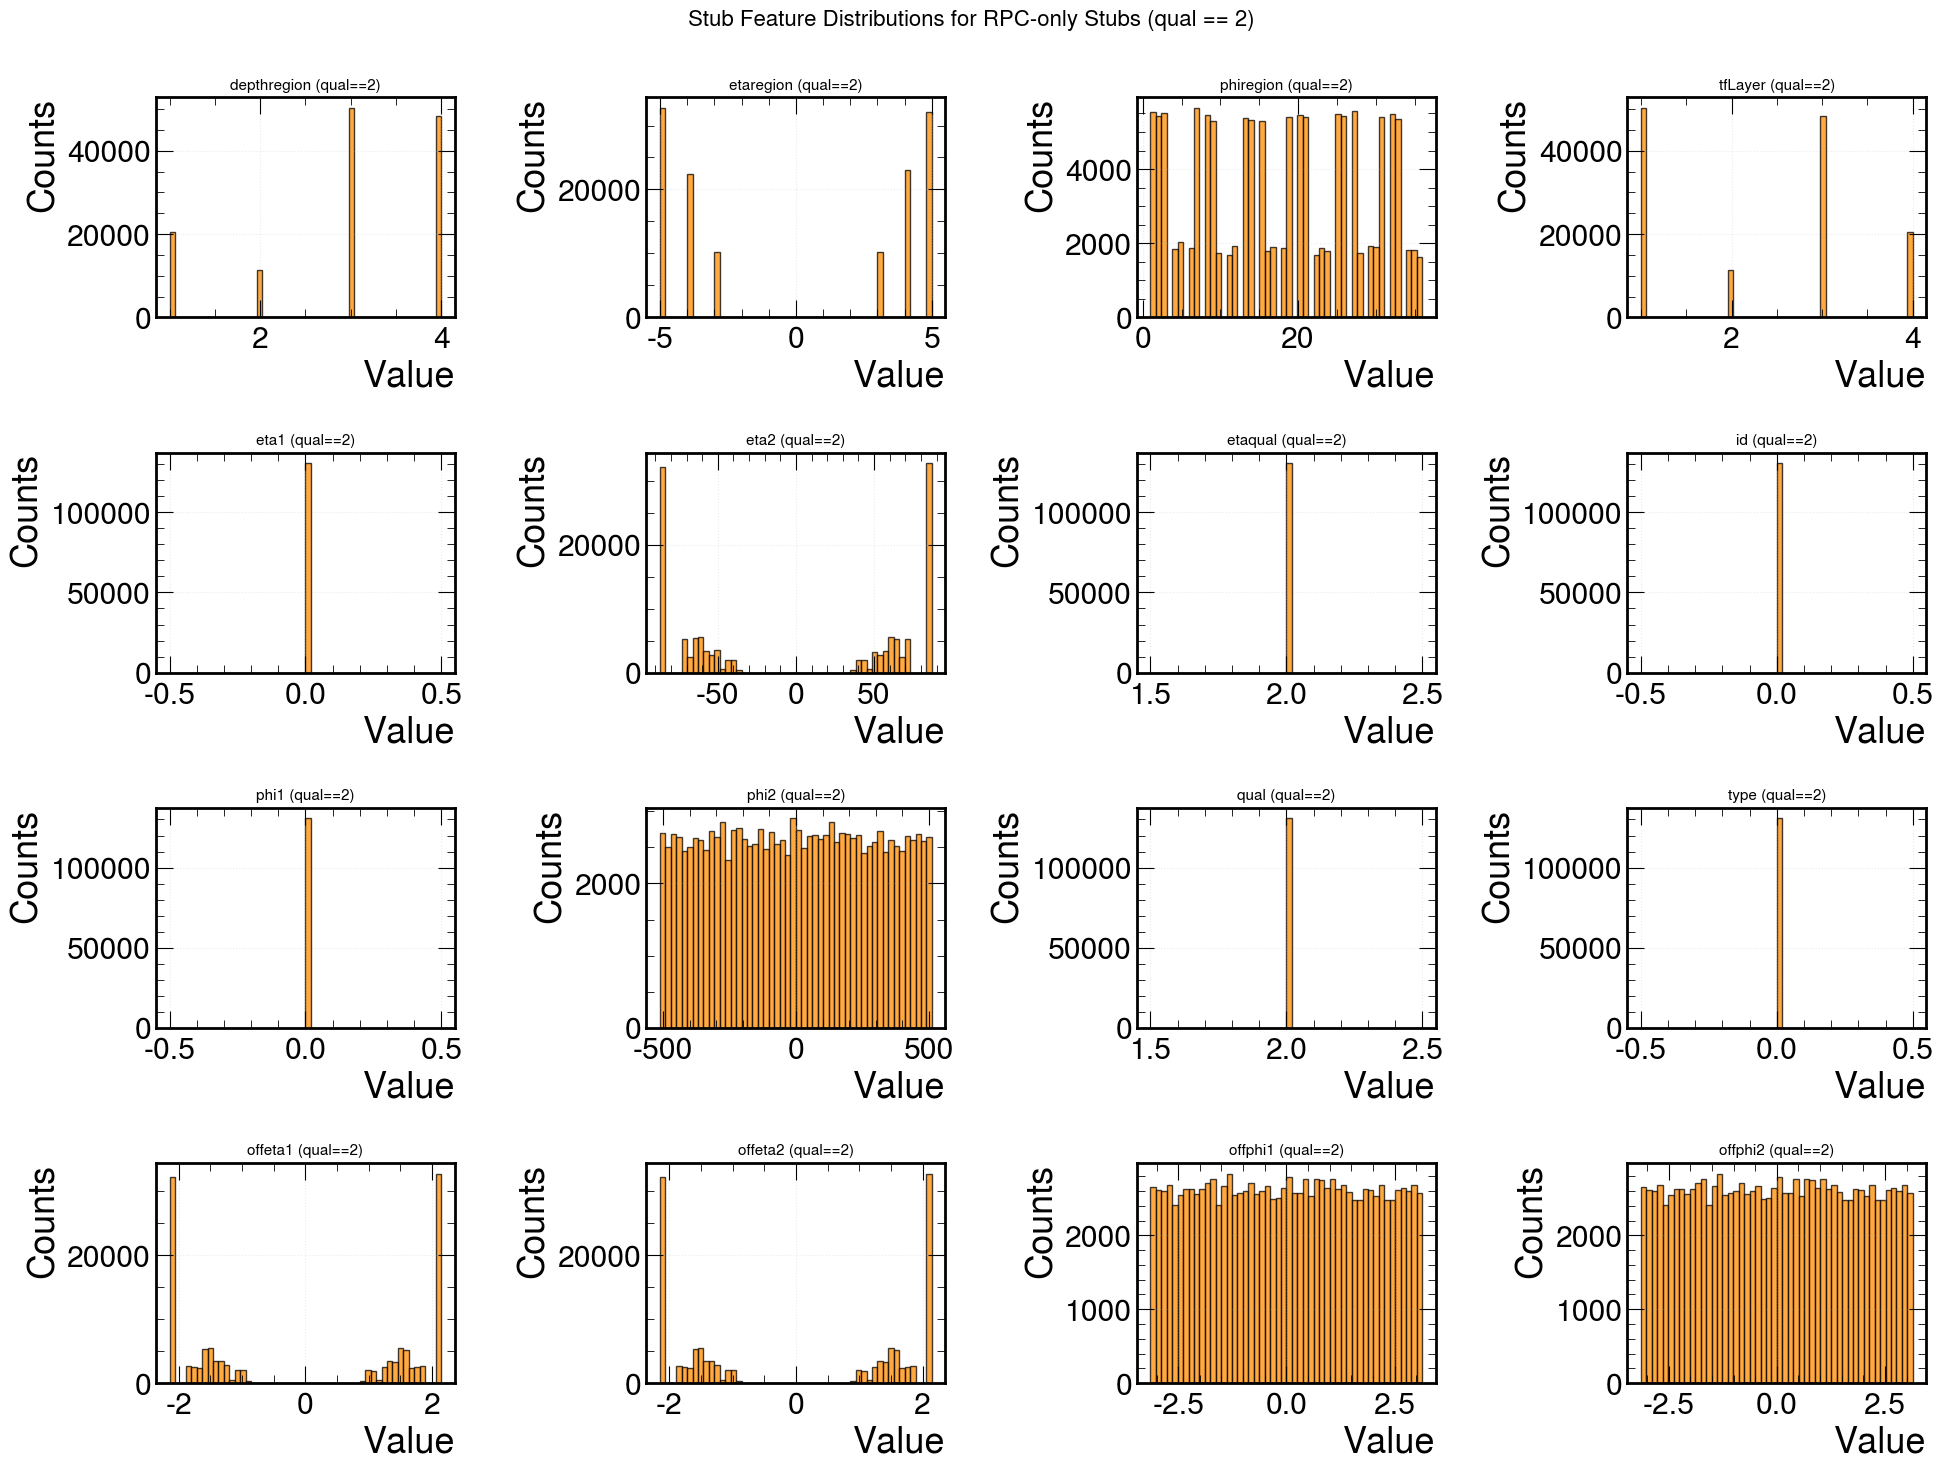

In [ ]:
# Select RPC-only stubs (quality == 2)
rpc_mask = data_events.stub.qual == 2 

n_rpc_stubs = int(ak.sum(rpc_mask))
n_total_stubs = int(ak.sum(ak.ones_like(data_events.stub.qual)))

print(f"RPC-only stubs (qual==2): {n_rpc_stubs} / {n_total_stubs} ({100*n_rpc_stubs/n_total_stubs:.2f}%)")

# Plot the same features as before, but only for RPC-only stubs
rpc_plot_features = plot_features  # keep same ordering/features used previously

n_feat = len(rpc_plot_features)
ncols = 4
nrows = int(np.ceil(n_feat / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, feat in enumerate(rpc_plot_features):
    ax = axes[i]
    try:
        vals = ak.to_numpy(ak.flatten(data_events.stub[feat][rpc_mask], axis=None))
        vals = vals[np.isfinite(vals)] if np.issubdtype(vals.dtype, np.number) else vals

        if vals.size > 0:
            ax.hist(vals, bins=50, alpha=0.75, edgecolor="black", color="darkorange")
        else:
            ax.text(0.5, 0.5, "No entries", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(f"{feat} (qual==2)", fontsize=11)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")
        ax.grid(True, alpha=0.25)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{feat} (qual==2)", fontsize=11)
        ax.axis("off")

# Hide any unused axes
for j in range(n_feat, len(axes)):
    axes[j].axis("off")

fig.suptitle("Stub Feature Distributions for RPC-only Stubs (qual == 2)", fontsize=16)
plt.tight_layout()
plt.show()

CSC-only stubs (qual==1): 276264 / 692436 (39.90%)


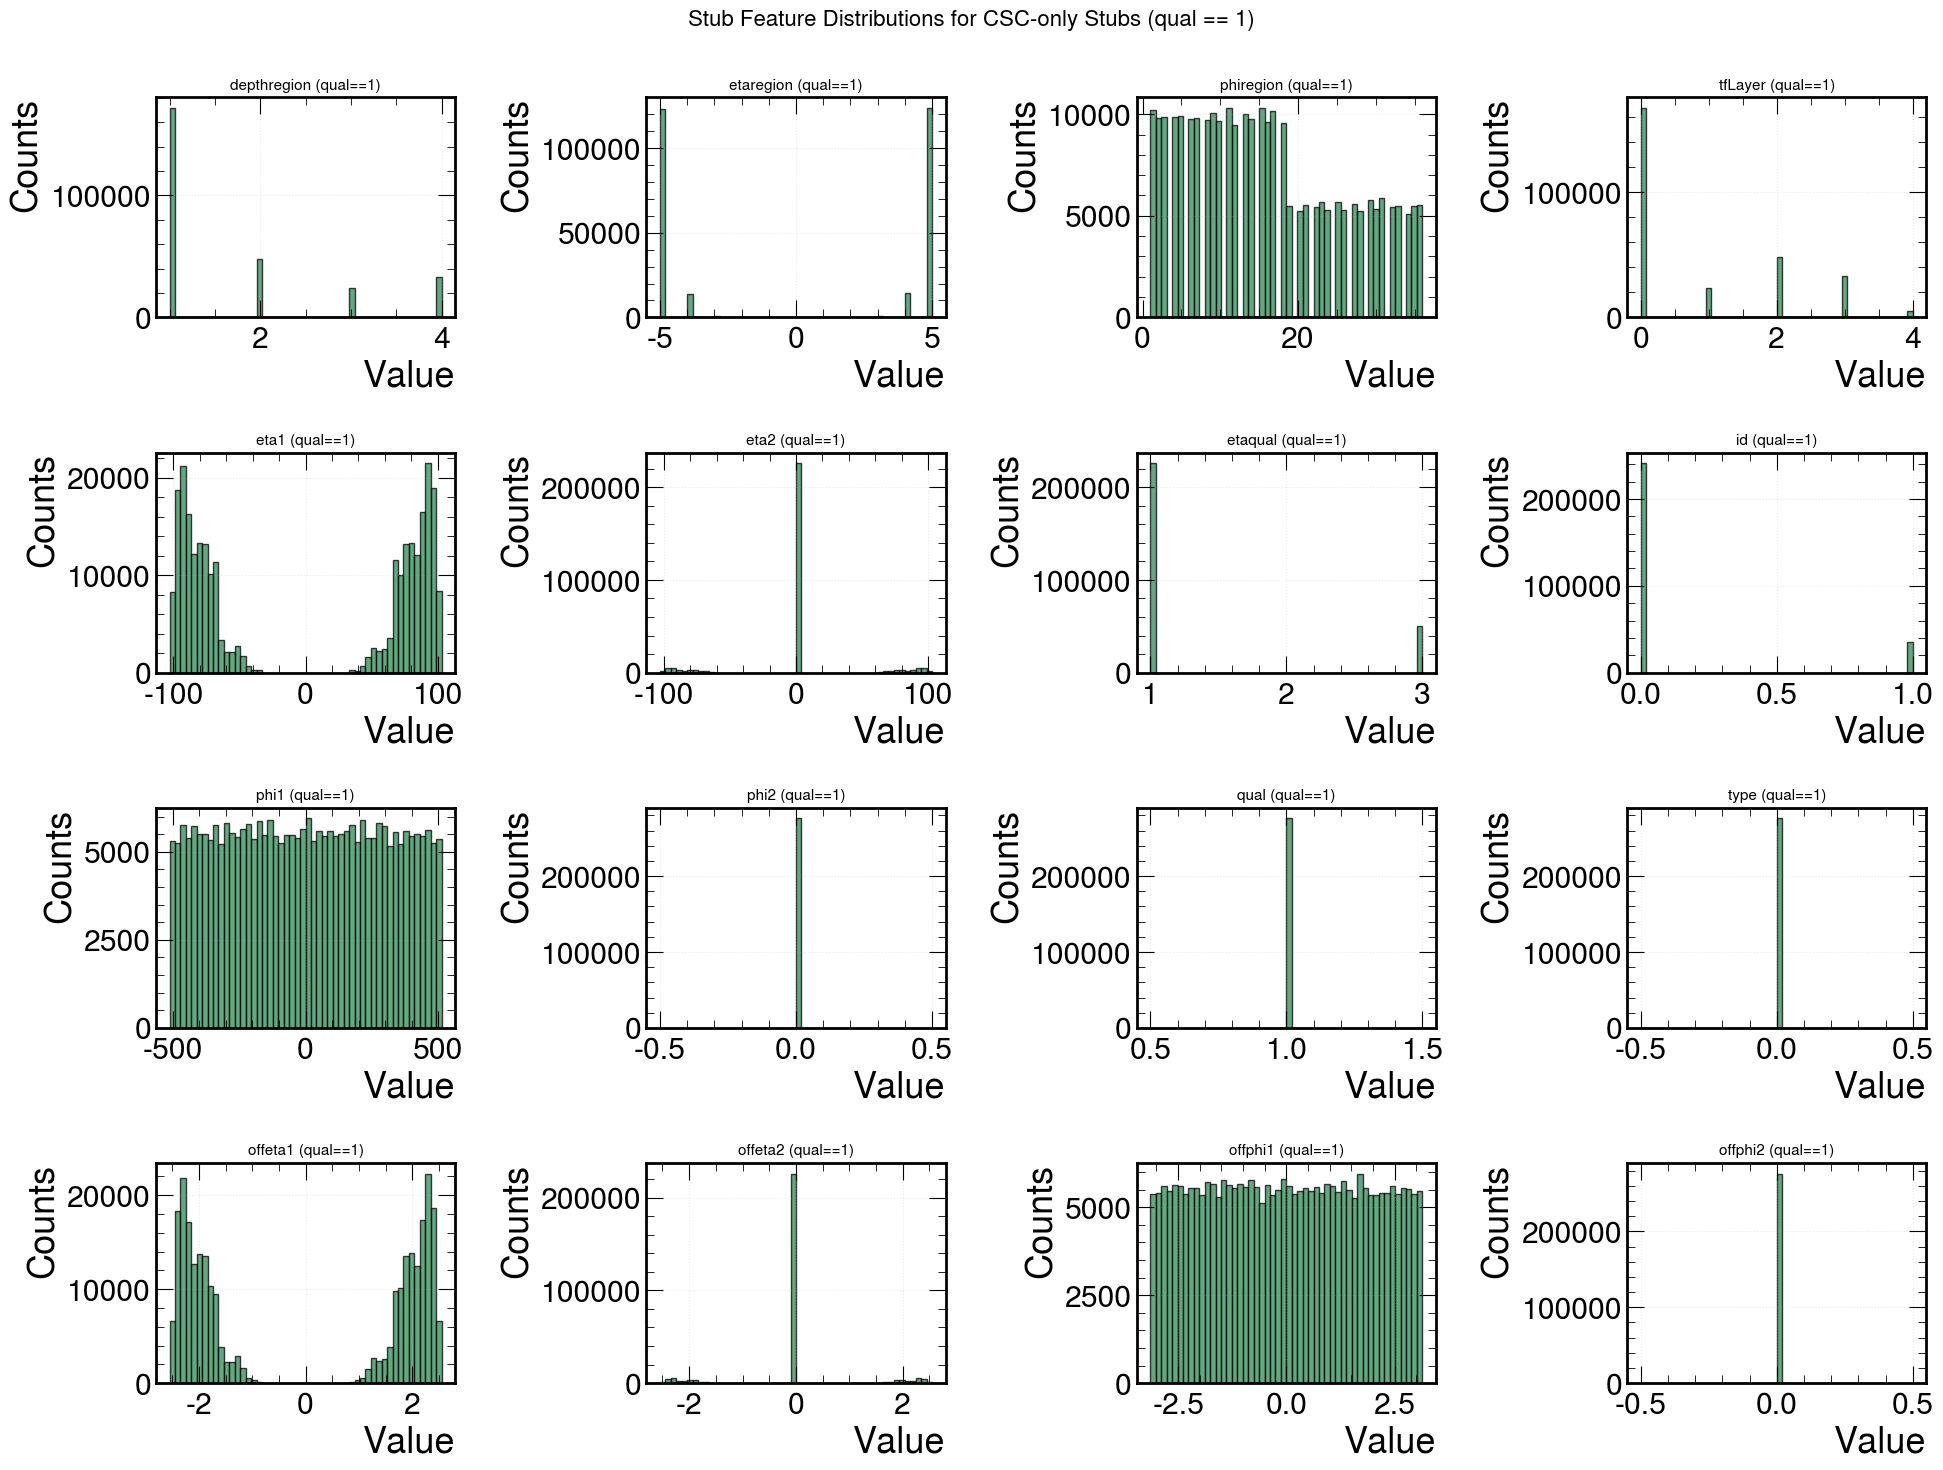

In [10]:
# Select CSC-only stubs (quality == 1)
csc_mask = data_events.stub.qual == 1

n_csc_stubs = int(ak.sum(csc_mask))
n_total_stubs = int(ak.sum(ak.ones_like(data_events.stub.qual)))

print(f"CSC-only stubs (qual==1): {n_csc_stubs} / {n_total_stubs} ({100*n_csc_stubs/n_total_stubs:.2f}%)")

# Plot the same features as before, but only for CSC-only stubs
csc_plot_features = plot_features  # keep same ordering/features used previously

n_feat = len(csc_plot_features)
ncols = 4
nrows = int(np.ceil(n_feat / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, feat in enumerate(csc_plot_features):
    ax = axes[i]
    try:
        vals = ak.to_numpy(ak.flatten(data_events.stub[feat][csc_mask], axis=None))
        vals = vals[np.isfinite(vals)] if np.issubdtype(vals.dtype, np.number) else vals

        if vals.size > 0:
            ax.hist(vals, bins=50, alpha=0.75, edgecolor="black", color="seagreen")
        else:
            ax.text(0.5, 0.5, "No entries", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(f"{feat} (qual==1)", fontsize=11)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")
        ax.grid(True, alpha=0.25)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{feat} (qual==1)", fontsize=11)
        ax.axis("off")

# Hide any unused axes
for j in range(n_feat, len(axes)):
    axes[j].axis("off")

fig.suptitle("Stub Feature Distributions for CSC-only Stubs (qual == 1)", fontsize=16)
plt.tight_layout()
plt.show()

qual==3 stubs: 86482 / 692436 (12.49%)


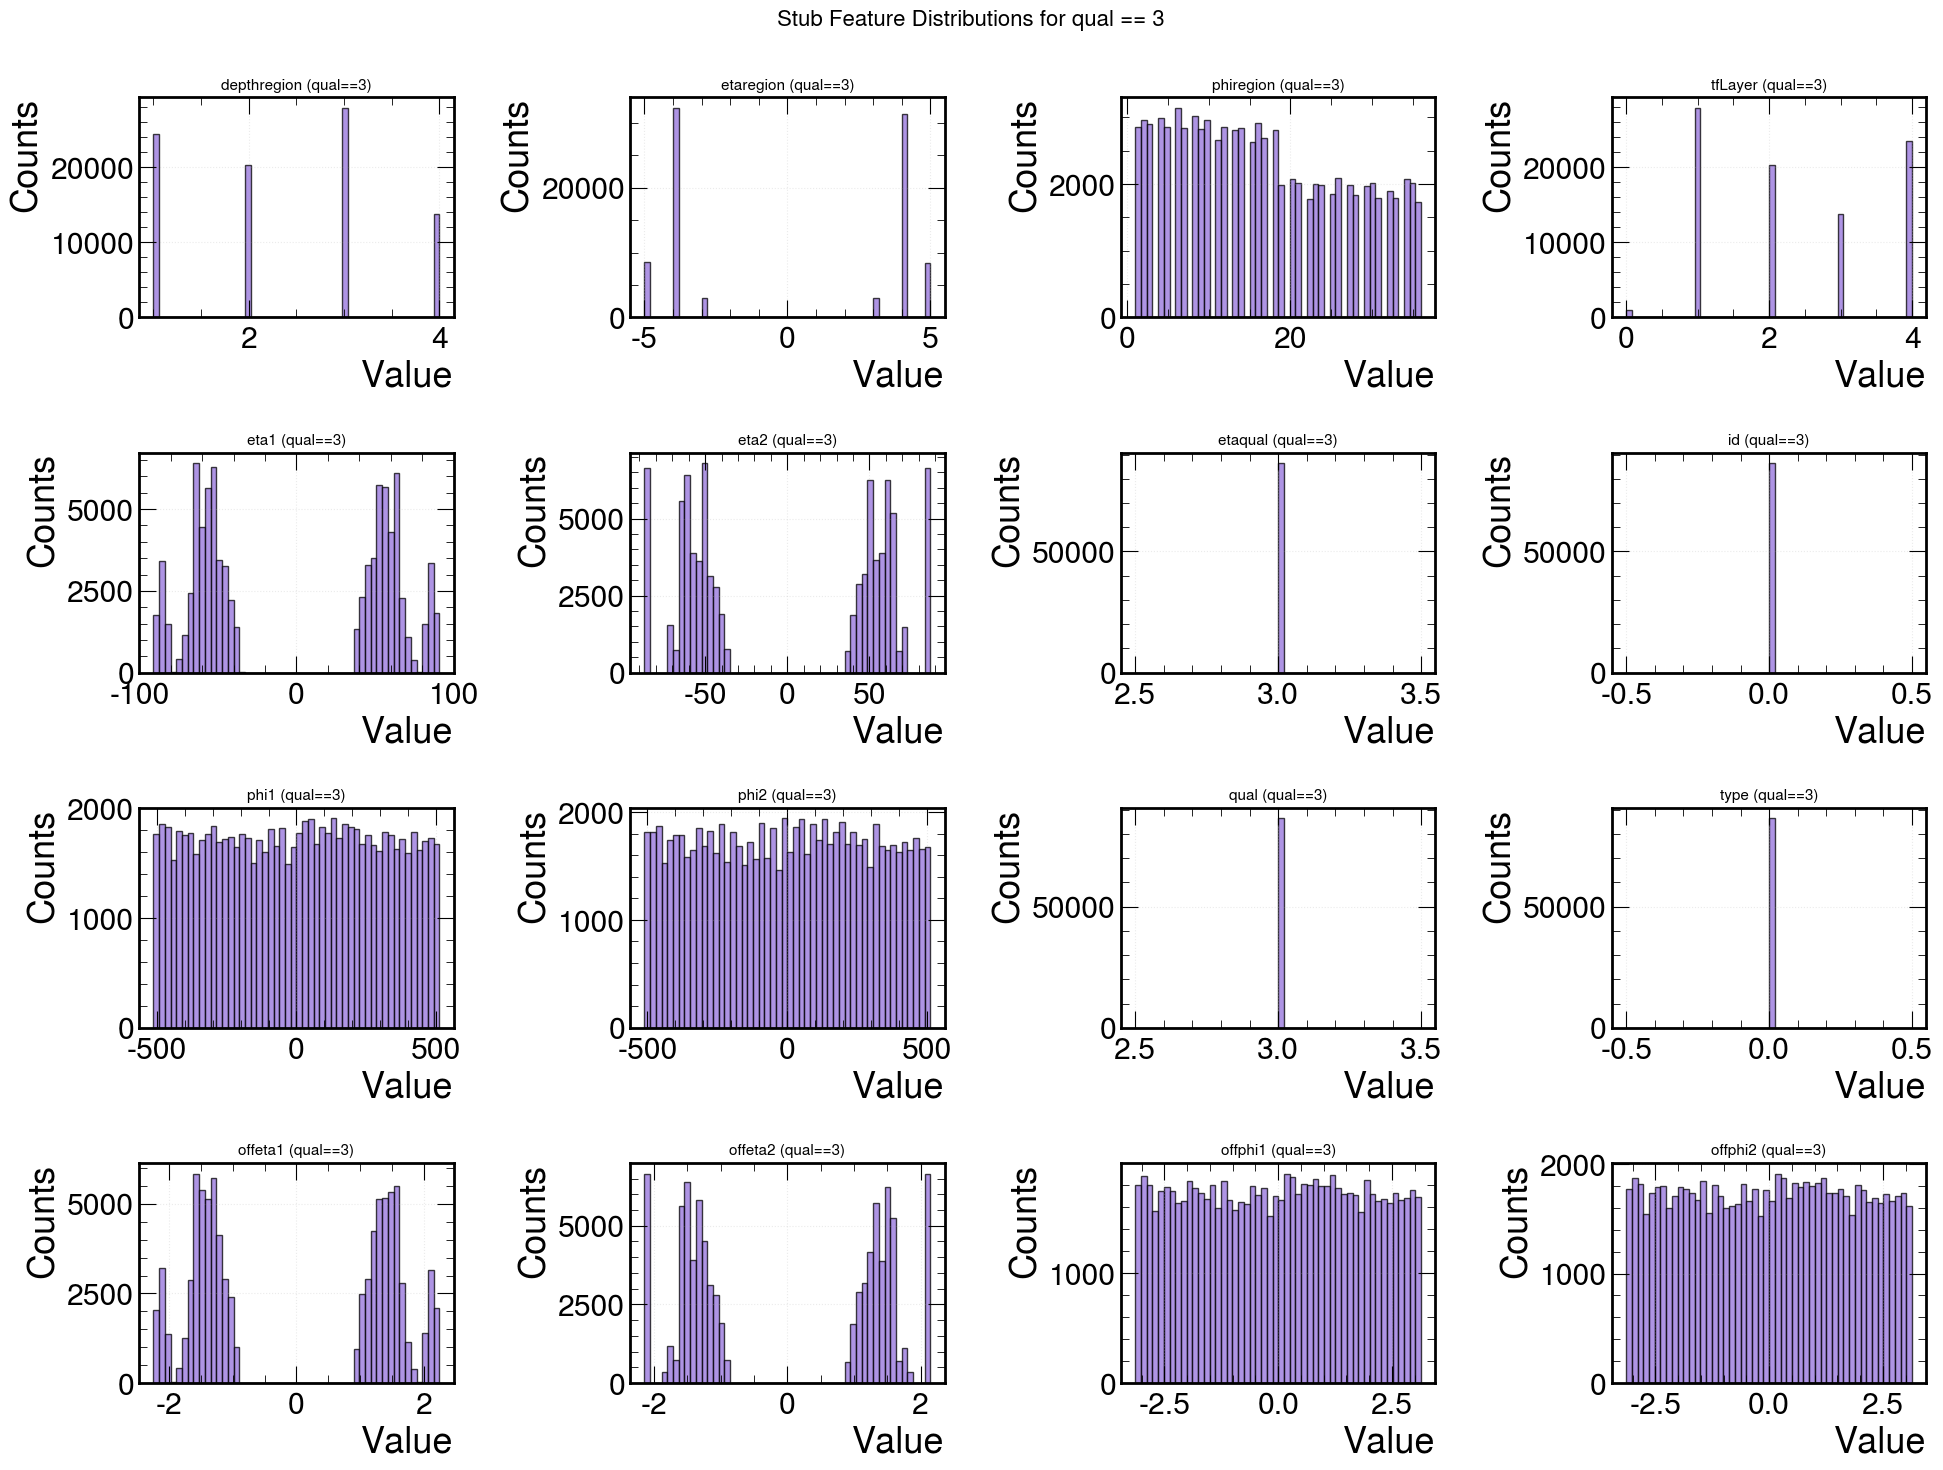

In [15]:
# Select stubs with qual == 3 (typically mixed/other category, often CSC+DT depending on encoding)
q3_mask = (data_events.stub.qual == 3) & (data_events.stub.isEndcap)

n_q3_stubs = int(ak.sum(q3_mask))
n_total_stubs_q = int(ak.sum(ak.ones_like(data_events.stub.qual)))
print(f"qual==3 stubs: {n_q3_stubs} / {n_total_stubs_q} ({100*n_q3_stubs/n_total_stubs_q:.2f}%)")

# Reuse the same feature list already built
q3_plot_features = plot_features

n_feat = len(q3_plot_features)
ncols = 4
nrows = int(np.ceil(n_feat / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, feat in enumerate(q3_plot_features):
    ax = axes[i]
    try:
        vals = ak.to_numpy(ak.flatten(data_events.stub[feat][q3_mask], axis=None))
        if np.issubdtype(vals.dtype, np.number):
            vals = vals[np.isfinite(vals)]

        if vals.size > 0:
            ax.hist(vals, bins=50, alpha=0.75, edgecolor="black", color="mediumpurple")
        else:
            ax.text(0.5, 0.5, "No entries", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(f"{feat} (qual==3)", fontsize=11)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")
        ax.grid(True, alpha=0.25)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{feat} (qual==3)", fontsize=11)
        ax.axis("off")

for j in range(n_feat, len(axes)):
    axes[j].axis("off")

fig.suptitle("Stub Feature Distributions for qual == 3", fontsize=16)
plt.tight_layout()
plt.show()

# Match stubs and gen muons 

Total stubs: 332624
Total gen muons (filtered with pdgId==13 and valid St2): 41072

=== RESULTS OF MATCHING ===
Total stubs: 332624
Stubs matched with muons: 157099 (47.23%)
Stubs without match (in events with muons): 140346 (42.19%)
Stubs in events without muons: 35179 (10.58%)

Delta R threshold used: 0.3
Average Delta R for matched stubs: 0.0651
Maximum Delta R for matched stubs: 0.3000


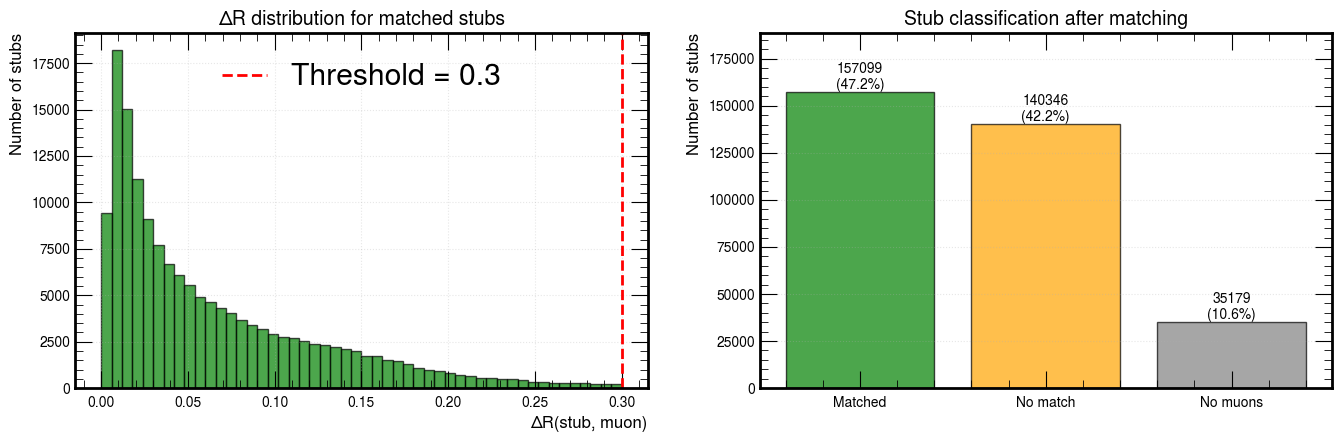

In [ ]:
import torch

def deltaphi(phi1, phi2):
    """Calculate the difference between two angles, accounting for periodicity."""
    dphi = phi1 - phi2
    while dphi > 3.14159:
        dphi -= 2 * 3.14159
    while dphi < -3.14159:
        dphi += 2 * 3.14159
    return dphi

# Función para calcular la distancia en el espacio eta-phi
def delta_R(eta1, phi1, eta2, phi2):
    """Calcula la distancia Delta R entre dos puntos en el espacio eta-phi"""
    deta = eta1 - eta2
    dphi = deltaphi(phi1,phi2)

    return np.sqrt(deta**2 + dphi**2)


mask_genmuons = (abs(data_events.GenPart.pdgId) == 13) & \
                ((data_events.GenPart.statusFlags & (1 << 13)) != 0) & \
                  (data_events.GenPart.pt > 1) & \
                  (data_events.GenPart.etaSt2 > -999)


# Extraer información de MB2 para todos los muones
etaSt2_all = ak.flatten(data_events.GenPart.etaSt2[mask_genmuons])
phiSt2_all = ak.flatten(data_events.GenPart.phiSt2[mask_genmuons])

# Convertir a numpy para hacer cálculos
etaSt2_np = ak.to_numpy(etaSt2_all)
phiSt2_np = ak.to_numpy(phiSt2_all)

# Extraer eta y phi offline de los stubs (usando offeta y offphi del centro del stub)
# Calculamos el promedio de offeta1 y offeta2, offphi1 y offphi2
stub_eta_offline = ak.to_numpy(ak.flatten(data_events.stub.offeta1))
stub_phi_offline = ak.to_numpy(ak.flatten(data_events.stub.offphi1))

# Obtener índices de evento para cada stub y muón
# Crear máscaras de eventos
stub_event_mask = ak.flatten(
    ak.ones_like(data_events.stub.offeta1) * 
    ak.local_index(data_events.stub.offeta1, axis=0)
)
genpart_event_mask = ak.flatten(
    ak.ones_like(data_events.GenPart.eta[mask_genmuons]) * 
    ak.local_index(data_events.GenPart.eta[mask_genmuons], axis=0)
)

stub_event_idx = ak.to_numpy(stub_event_mask)
genpart_event_idx = ak.to_numpy(genpart_event_mask)

print(f"Total stubs: {len(stub_eta_offline)}")
print(f"Total gen muons (filtered with pdgId==13 and valid St2): {len(etaSt2_np)}")

# Inicializar arrays para las etiquetas
stub_labels = np.full(len(stub_eta_offline), -1, dtype=np.int32)  # -1 indica sin match
stub_deltaR = np.full(len(stub_eta_offline), 999.0, dtype=np.float32)  # distancia mínima
stub_matched_muon_idx = np.full(len(stub_eta_offline), -1, dtype=np.int32)  # índice del muón matched

# Threshold para considerar un match (en unidades de Delta R)
deltaR_threshold = 0.3

# Para cada stub, buscar el muón de generación más cercano en el mismo evento
for stub_idx in range(len(stub_eta_offline)):
    stub_evt = stub_event_idx[stub_idx]
    stub_eta = stub_eta_offline[stub_idx]
    stub_phi = stub_phi_offline[stub_idx]
    
    # Encontrar muones en el mismo evento
    muons_in_event = np.where(genpart_event_idx == stub_evt)[0]
    
    if len(muons_in_event) == 0:
        continue
    
    # Calcular distancia a todos los muones del evento
    best_deltaR = 999.0
    best_muon_idx = -1
    
    for muon_idx in muons_in_event:
        muon_etaSt2 = etaSt2_np[muon_idx]
        muon_phiSt2 = phiSt2_np[muon_idx]
        
        # Calcular Delta R
        dR = delta_R(stub_eta, stub_phi, muon_etaSt2, muon_phiSt2)
        
        if dR < best_deltaR:
            best_deltaR = dR
            best_muon_idx = muon_idx
    
    # Si encontramos un match dentro del threshold, asignarlo
    if best_deltaR < deltaR_threshold:
        stub_labels[stub_idx] = 1  # Match encontrado
        stub_deltaR[stub_idx] = best_deltaR
        stub_matched_muon_idx[stub_idx] = best_muon_idx
    else:
        stub_labels[stub_idx] = 0  # No match

# Convertir a tensores de PyTorch
stub_labels_tensor = torch.tensor(stub_labels, dtype=torch.long)
stub_deltaR_tensor = torch.tensor(stub_deltaR, dtype=torch.float32)
stub_matched_muon_idx_tensor = torch.tensor(stub_matched_muon_idx, dtype=torch.long)

# Estadísticas
n_matched = np.sum(stub_labels == 1)
n_unmatched = np.sum(stub_labels == 0)
n_no_muons = np.sum(stub_labels == -1)

print(f"\n=== RESULTS OF MATCHING ===")
print(f"Total stubs: {len(stub_labels)}")
print(f"Stubs matched with muons: {n_matched} ({100*n_matched/len(stub_labels):.2f}%)")
print(f"Stubs without match (in events with muons): {n_unmatched} ({100*n_unmatched/len(stub_labels):.2f}%)")
print(f"Stubs in events without muons: {n_no_muons} ({100*n_no_muons/len(stub_labels):.2f}%)")
print(f"\nDelta R threshold used: {deltaR_threshold}")
print(f"Average Delta R for matched stubs: {np.mean(stub_deltaR[stub_labels == 1]):.4f}")
print(f"Maximum Delta R for matched stubs: {np.max(stub_deltaR[stub_labels == 1]):.4f}")

# Visualize Delta R distribution for matched stubs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Delta R for matched stubs
matched_deltaR = stub_deltaR[stub_labels == 1]
axes[0].hist(matched_deltaR, bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0].axvline(deltaR_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {deltaR_threshold}')
axes[0].set_xlabel('ΔR(stub, muon)')
axes[0].set_ylabel('Number of stubs')
axes[0].set_title('ΔR distribution for matched stubs', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='both', labelsize=10)
axes[0].xaxis.label.set_size(12)
axes[0].yaxis.label.set_size(12)
axes[0].legend()

# Bar chart with statistics
categories = ['Matched', 'No match', 'No muons']
counts = [n_matched, n_unmatched, n_no_muons]
colors = ['green', 'orange', 'gray']
bars = axes[1].bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Number of stubs')
axes[1].set_title('Stub classification after matching', fontsize=14)
axes[1].tick_params(axis='both', labelsize=10)
axes[1].xaxis.label.set_size(12)
axes[1].yaxis.label.set_size(12)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, max(counts)*1.2)

# Add values on the bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({100*count/len(stub_labels):.1f}%)',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Prepare dataset for training 

In [ ]:
# Definir lista de variables a usar
STUB_FEATURES = [
    'coord1',     # feature 1
    'coord2',     # feature 2
    'eta1',       # feature 3
    'eta2',       # feature 4
    'quality',    # feature 5  
]

MATCHING_FEATURES = [
    'label',         # feature 3: 1 (matched), 0 (no match), -1 (sin muones)
    'deltaR',        # feature 4: distancia mínima al muón matched
    'matched_idx',   # feature 5: índice del muón matched
]

GENPART_FEATURES = [
    'pt',        # feature 0
    'eta',       # feature 1
    'phi',       # feature 2
    'pdgId',     # feature 4
    'dXY',       # feature 5
    'lXY',       # feature 6
]

In [ ]:
import torch
import awkward as ak
import numpy as np



# ===== CREAR TENSORES DE STUBS CON MATCHING =====
# Aplanar stubs de todos los eventos
stub_data = {}
for i, feature in enumerate(STUB_FEATURES):
    stub_array = ak.flatten(data_events.stub[feature])
    stub_data[feature] = torch.tensor(
        ak.to_numpy(stub_array), 
        dtype=torch.float32
    )

# Añadir features de matching
stub_data['label'] = torch.tensor(stub_labels, dtype=torch.float32)
stub_data['deltaR'] = torch.tensor(stub_deltaR, dtype=torch.float32)
stub_data['matched_idx'] = torch.tensor(stub_matched_muon_idx, dtype=torch.float32)

# Stack todas las features en un tensor [num_stubs_total, num_features + matching]
stub_tensor = torch.stack(
    [stub_data[f] for f in STUB_FEATURES] + 
    [stub_data[f] for f in MATCHING_FEATURES],
    dim=1
)

print(f"\nStub tensor shape: {stub_tensor.shape}")
print(f"  Features originales: {len(STUB_FEATURES)}")
print(f"  Features de matching: {len(MATCHING_FEATURES)}")
print(f"  Total features: {stub_tensor.shape[1]}")
print(f"  Total stubs: {stub_tensor.shape[0]}")

# Crear máscara de eventos para cada stub
stub_event_indices = torch.tensor(
    ak.to_numpy(stub_event_mask),
    dtype=torch.long
)

# ===== TENSORES DE GENPART (MUONES) =====
genpart_data = {}

for i, feature in enumerate(GENPART_FEATURES):
    genpart_array = ak.flatten(data_events.GenPart[feature][mask_genmuons])
    genpart_data[feature] = torch.tensor(
        ak.to_numpy(genpart_array),
        dtype=torch.float32
    )

genpart_tensor = torch.stack(
    [genpart_data[f] for f in GENPART_FEATURES],
    dim=1
)

genpart_event_indices = torch.tensor(
    ak.to_numpy(genpart_event_mask),
    dtype=torch.long
)

# Resumen
print(f"\n=== RESUMEN ===")
print(f"Stub features ({len(STUB_FEATURES)}): {STUB_FEATURES}")
print(f"Matching features ({len(MATCHING_FEATURES)}): {MATCHING_FEATURES}")
print(f"GenPart features ({len(GENPART_FEATURES)}): {GENPART_FEATURES}")
print(f"\nTensores creados:")
print(f"  stub_tensor: {stub_tensor.shape} (stubs, features+matching)")
print(f"  genpart_tensor: {genpart_tensor.shape} (muones, features)")


Stub tensor shape: torch.Size([332624, 6])
  Features originales: 3
  Features de matching: 3
  Total features: 6
  Total stubs: 332624

=== RESUMEN ===
Stub features (3): ['tfLayer', 'offeta1', 'offphi1']
Matching features (3): ['label', 'deltaR', 'matched_idx']
GenPart features (6): ['pt', 'eta', 'phi', 'pdgId', 'dXY', 'lXY']

Tensores creados:
  stub_tensor: torch.Size([332624, 6]) (stubs, features+matching)
  genpart_tensor: torch.Size([41072, 6]) (muones, features)


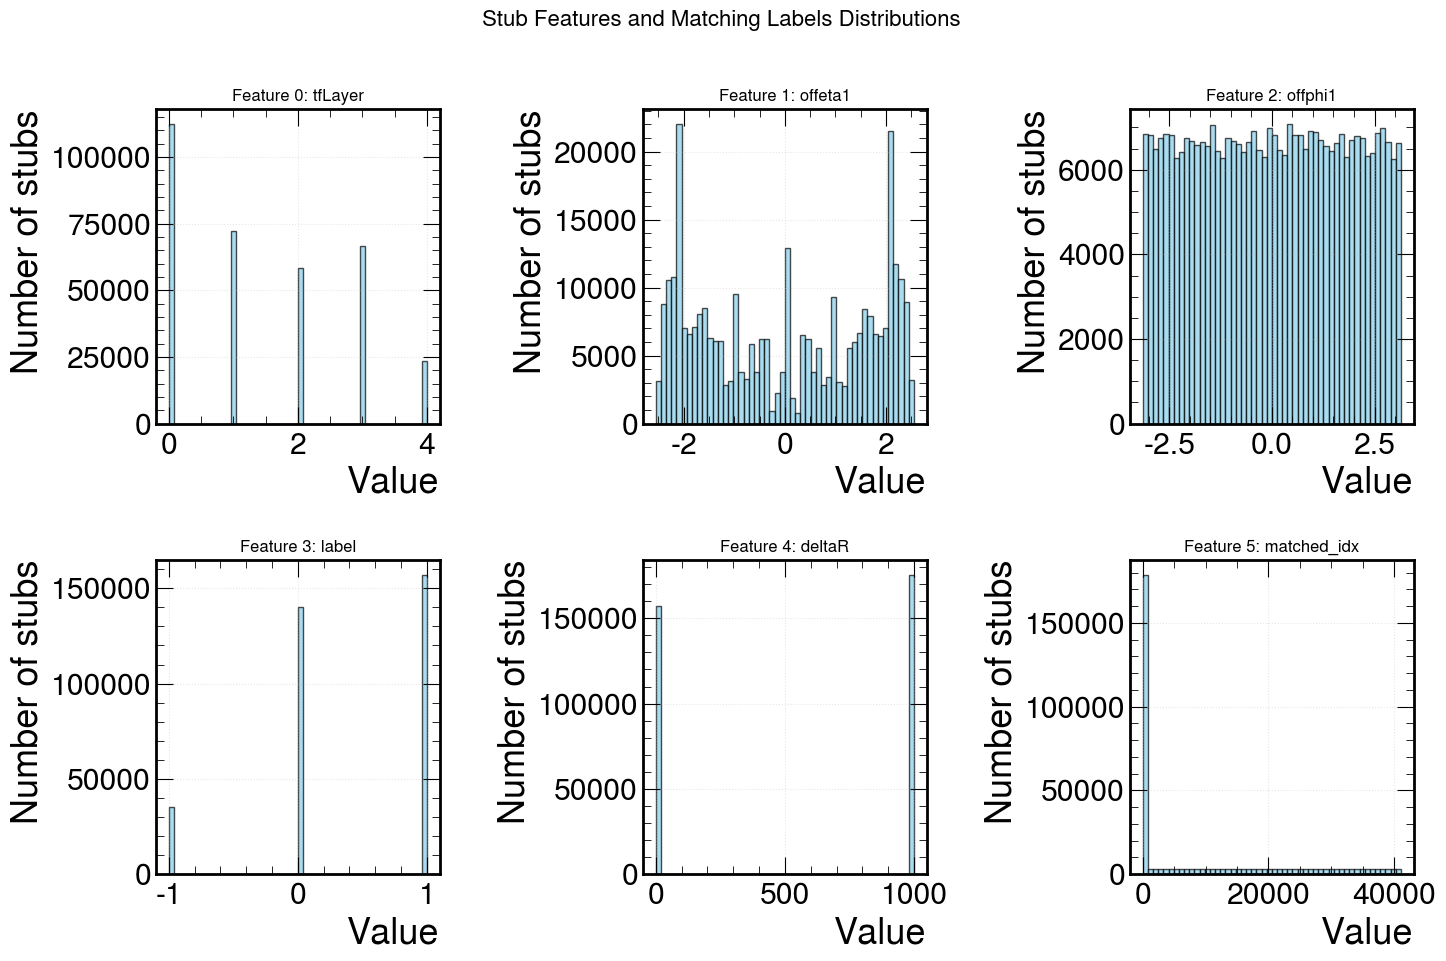

In [ ]:
## plot all the node features distributions and matching labels
num_stub_features = stub_tensor.shape[1]
fig, axes = plt.subplots(2, (num_stub_features + 1) //
                        2, figsize=(15, 10))
fig.suptitle('Stub Features and Matching Labels Distributions', fontsize=16)
for i in range(num_stub_features):
    ax = axes[i // ((num_stub_features + 1) // 2), i %
                  ((num_stub_features + 1) // 2)]
    feature_data = stub_tensor[:, i].numpy()
    ax.hist(feature_data, bins=50, alpha=0.7, edgecolor='black', color='skyblue')
    ax.set_title(f'Feature {i}: {STUB_FEATURES[i] if i < len(STUB_FEATURES) else MATCHING_FEATURES[i - len(STUB_FEATURES)]}', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Number of stubs')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Define deltaphi function if not already defined
def deltaphi(phi1, phi2):
    """Calculate the difference between two angles, accounting for periodicity."""
    dphi = phi1 - phi2
    while dphi > 3.14159:
        dphi -= 2 * 3.14159
    while dphi < -3.14159:
        dphi += 2 * 3.14159
    return dphi

from torch_geometric.data import Data

debug=False

print("Reconstructing graphs with edge attributes and edge labels...")
print("Graph structure:")
print("  - Nodes: stubs (with features tfLayer, offeta1, offphi1, label)")
print("  - Edges: connection between stubs of consecutive tfLayers (if deta<0.5 and dphi<1.0)")
print("  - Edge attributes: [deta, dphi] between the connected stubs")
print("  - Edge labels: 1 if both stubs are matched to the same muon, 0 otherwise")


# Agrupar stubs por evento para construir grafos individuales
graphs = []

# Eventos únicos
unique_events = torch.unique(stub_event_indices)

## print only first event: 
print(f"\nTotal eventos: {len(unique_events)}")

# Process each  event
for event_id in unique_events:

    # Get stubs for this event
    mask_event = stub_event_indices == event_id
    stub_indices = torch.where(mask_event)[0]    

    if len(stub_indices) == 0:
        continue
    
    # Extract features for this event
    x = stub_tensor[stub_indices]

    if event_id.item() == 2 and debug:
        print(f"\nProcessing event {event_id.item()} with {x.shape[0]} stubs")
        print(f"  All stubs (tfLayer, offeta1, offphi1, label):")
        for i in range(x.shape[0]):
            print(f"    Stub {i}: tfLayer={x[i,0].item()}, offeta1={x[i,1].item():.2f}, offphi1={x[i,2].item():.2f}, label={x[i,3].item()}, deltaR={x[i,4].item():.3f}, matched_idx={x[i,5].item()}")
    valid_mask = x[:, 3] >= 0
    if valid_mask.sum() == 0:
        continue
    x = x[valid_mask]
    

    tfLayer_evt = x[:, 0]  # tfLayer is feature 0
    
    # Build edges connecting stubs between consecutive tfLayers
    edges = []
    edge_attrs = []  # Edge attributes: [deta, dphi]
    edge_labels = []  # Edge labels: 1 if both matched to the same muon, 0 otherwise

    # Find unique layers in this event
    unique_layers_evt = torch.unique(tfLayer_evt, sorted=True)
    if event_id.item() == 0 and debug:
        print(f"Event {event_id.item()}: unique layers = {unique_layers_evt.tolist()}")
    
    # Connect consecutive layers (and also the subsequent one if needed)
    for layer_idx in range(len(unique_layers_evt) - 1):
        L_curr = unique_layers_evt[layer_idx]
        L_next = unique_layers_evt[layer_idx + 1]
        # Also get the subsequent layer if it exists
        L_next_next = unique_layers_evt[layer_idx + 2] if layer_idx + 2 < len(unique_layers_evt) else None
        
        if event_id.item() == 0 and debug:
            print("Current layer:", L_curr.item(), "Next layer:", L_next.item(), "Next next layer:", L_next_next.item() if L_next_next is not None else "None")

        # Local indices of stubs in each layer (relative to the event)
        local_idx_curr = torch.where(tfLayer_evt == L_curr)[0]
        local_idx_next = torch.where(tfLayer_evt == L_next)[0]
        local_idx_next_next = torch.where(tfLayer_evt == L_next_next)[0] if L_next_next is not None else []
        
        if event_id.item() == 0 and debug:
            print(f"  Stubs in layer {L_curr.item()}: {local_idx_curr.tolist()}")
            print(f"  Stubs in layer {L_next.item()}: {local_idx_next.tolist()}")
            if L_next_next is not None:
                print(f"  Stubs in layer {L_next_next.item()}: {local_idx_next_next.tolist()}")
                
        # Connect each stub in the current layer with nodes in the next (and subsequent if needed)
        for i in local_idx_curr:
            offeta1 = x[i, 1]
            offphi1 = x[i, 2]
            matched_muon_i = x[i, 3].item()  # Label of stub i

            connected_to_next = False
            
            # First try to connect with the next layer
            for j in local_idx_next:
                offeta2 = x[j, 1]
                offphi2 = x[j, 2]
                matched_muon_j = x[j, 3].item()  # Label of stub j

                deta = (offeta1 - offeta2)
                dphi = deltaphi(offphi1, offphi2)

                # Connect if they are close (with similar tolerances)
                if abs(deta) < 0.5 and abs(dphi) < 1.0:
                    edges.append([i.item(), j.item()])
                    edge_attrs.append([deta.item(), dphi.item()])
                    
                    # Edge label: 1 if both stubs belong to the same muon (matched_muon >= 0)
                    # 0 if at least one is not matched or they are matched to different muons
                    if matched_muon_i >= 0 and matched_muon_j >= 0 and matched_muon_i == matched_muon_j:
                        edge_labels.append(1)
                    else:
                        edge_labels.append(0)

                    connected_to_next = True

                if event_id.item() == 0 and L_curr.item()==1 and debug:
                    print(f"    Comparing stub {i.item()} (layer {L_curr.item()}, eta={offeta1:.2f}, phi={offphi1:.2f}) with stub {j.item()} (layer {L_next.item()}, eta={offeta2:.2f}, phi={offphi2:.2f}): deta={deta:.2f}, dphi={dphi:.2f} -> {'Connected' if abs(deta) < 0.5 and abs(dphi) < 1.0 else 'Not connected'}")
            # If not connected to the next layer, try the subsequent one
            if not connected_to_next and L_next_next is not None:
                for k in local_idx_next_next:
                    offeta2 = x[k, 1]
                    offphi2 = x[k, 2]
                    matched_muon_k = x[k, 3].item()  # Label of stub k

                    deta = (offeta1 - offeta2)
                    dphi = deltaphi(offphi1, offphi2)

                    # Connect if they are close (with similar tolerances)
                    if abs(deta) < 0.5 and abs(dphi) < 1.0:
                        edges.append([i.item(), k.item()])
                        edge_attrs.append([deta.item(), dphi.item()])
                        
                        # Edge label
                        if matched_muon_i >= 0 and matched_muon_k >= 0 and matched_muon_i == matched_muon_k:
                            edge_labels.append(1)
                        else:
                            edge_labels.append(0)

                    if event_id.item() == 0 and L_curr.item()==1 and debug:
                        print(f"    Comparing stub {i.item()} (layer {L_curr.item()}, eta={offeta1:.2f}, phi={offphi1:.2f}) with stub in subsequent {k.item()} (layer {L_next_next.item()}, eta={offeta2:.2f}, phi={offphi2:.2f}): deta={deta:.2f}, dphi={dphi:.2f} -> {'Connected' if abs(deta) < 0.5 and abs(dphi) < 1.0 else 'Not connected'}")

    # Convert edges to tensor
    if len(edges) > 0:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
        edge_y = torch.tensor(edge_labels, dtype=torch.float)
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 2), dtype=torch.float)
        edge_y = torch.zeros(0, dtype=torch.float)
    
    # Extract node labels (4th feature: matched_muon_idx)
    nodes = x[:, :3]  # Keep only the first 3 features for node features
    node_labels = x[:, 3].clone()  # 1 if matched (>=0), 0 if not matched
    
    # Create PyG graph
    graph = Data(x=nodes, edge_index=edge_index, edge_attr=edge_attr, edge_y=edge_y, 
                 y=node_labels, num_nodes=len(nodes))
    graphs.append(graph)

    if len(graphs) <= 10 or len(graphs) % 1000 == 0:
        print(f"Event {event_id.item()}: nodes={x.shape[0]}, edges={edge_index.shape[1]}, layers={unique_layers_evt.tolist()}")


/Users/folgueras/anaconda3/envs/cmsl1t/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reconstructing graphs with edge attributes and edge labels...
Graph structure:
  - Nodes: stubs (with features tfLayer, offeta1, offphi1, label)
  - Edges: connection between stubs of consecutive tfLayers (if deta<0.5 and dphi<1.0)
  - Edge attributes: [deta, dphi] between the connected stubs
  - Edge labels: 1 if both stubs are matched to the same muon, 0 otherwise

Total eventos: 19477
Event 0: nodes=17, edges=20, layers=[0.0, 1.0, 2.0, 3.0, 4.0]
Event 1: nodes=30, edges=35, layers=[0.0, 1.0, 2.0, 3.0, 4.0]
Event 2: nodes=24, edges=27, layers=[0.0, 1.0, 2.0, 3.0, 4.0]
Event 3: nodes=26, edges=27, layers=[0.0, 1.0, 2.0, 3.0, 4.0]
Event 4: nodes=19, edges=16, layers=[0.0, 1.0, 2.0, 3.0, 4.0]
Event 5: nodes=15, edges=12, layers=[0.0, 1.0, 2.0, 3.0, 4.0]
Event 6: nodes=22, edges=17, layers=[0.0, 1.0, 2.0, 3.0, 4.0]
Event 7: nodes=32, edges=44, layers=[0.0, 1.0, 2.0, 3.0, 4.0]
Event 8: nodes=18, edges=9, layers=[0.0, 1.0, 2.0, 3.0]
Event 9: nodes=18, edges=23, layers=[0.0, 1.0, 2.0, 3.0, 

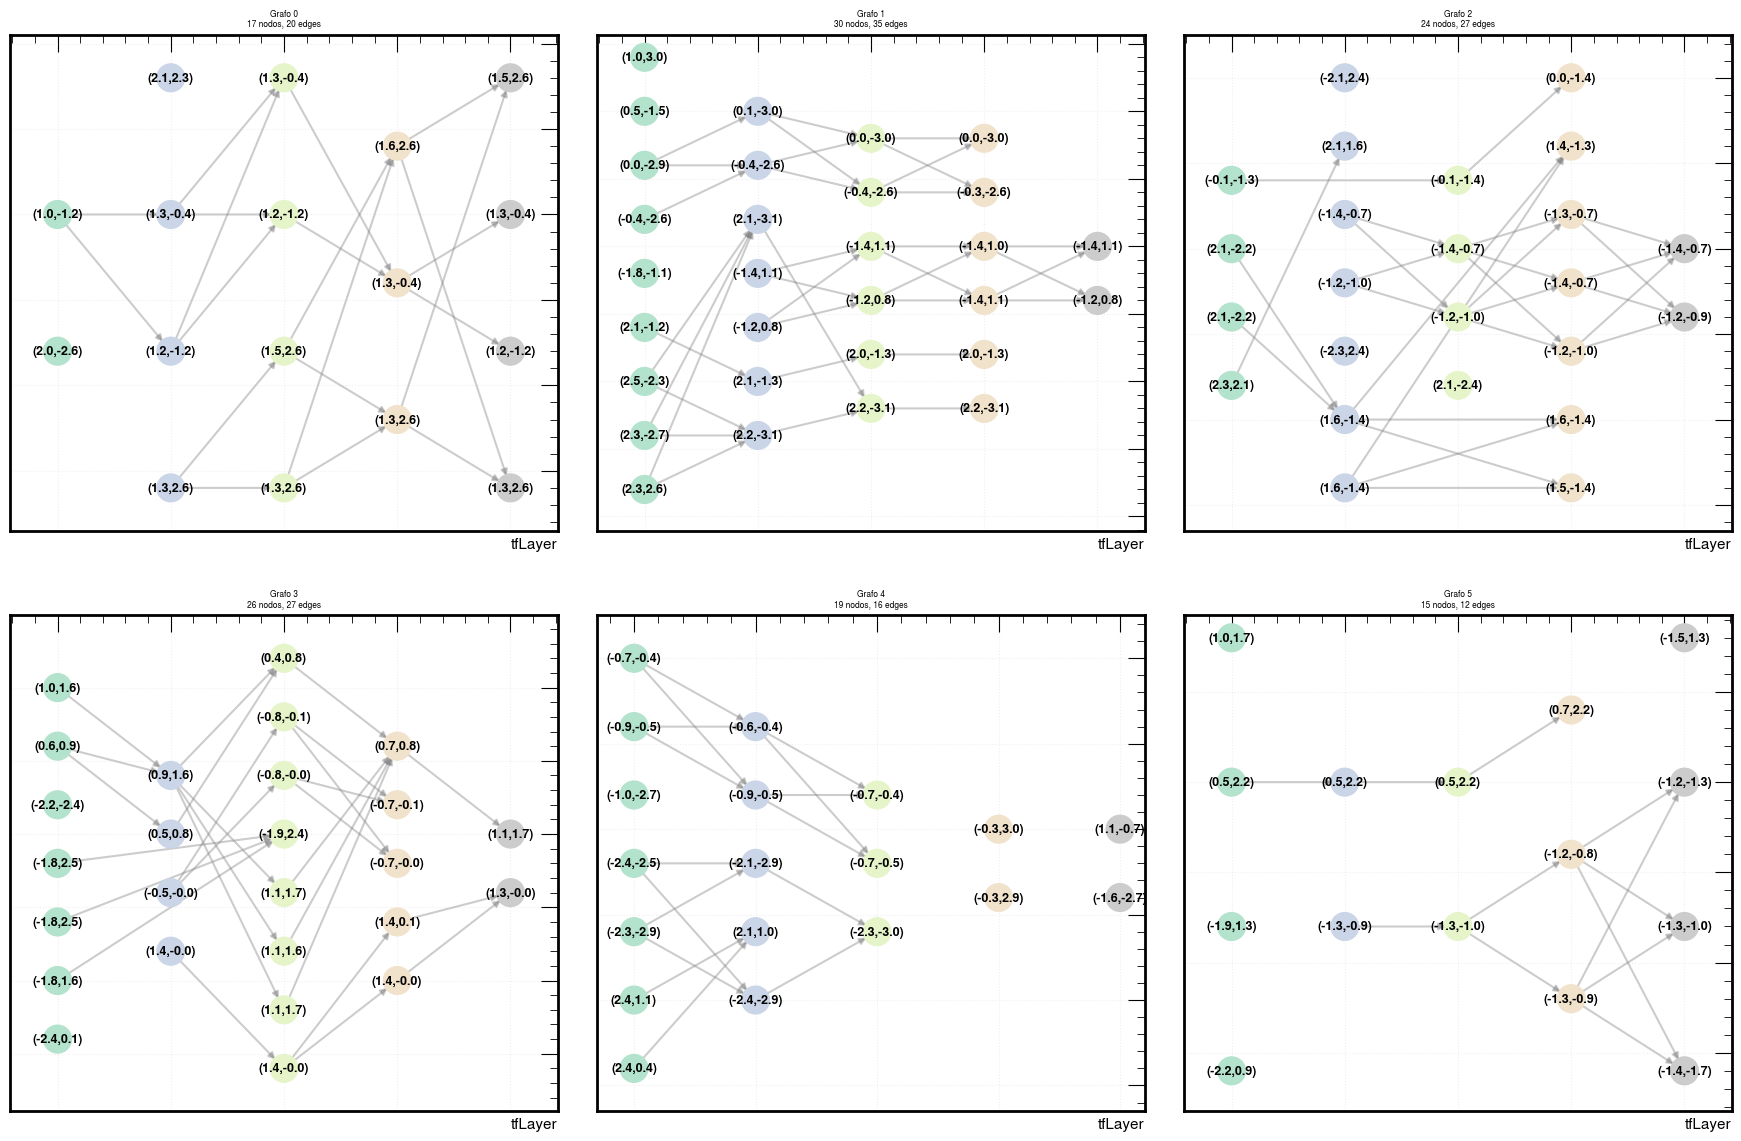


Visualizados 6 grafos de 15783 totales

First graph details:
  Number of nodes: 17
  Number of edges: 20
  Node features shape: torch.Size([17, 3])
  Edge index shape: torch.Size([2, 20])
  Edge attributes shape: torch.Size([20, 2])
  Edge labels shape: torch.Size([20])
  Node labels shape: torch.Size([17])

Nodes (features) - first 10 nodes:
  Node 0: tfLayer=0.0, offeta1=1.98, offphi1=-2.64, label=0.0
  Node 1: tfLayer=4.0, offeta1=1.28, offphi1=2.60, label=1.0
  Node 2: tfLayer=4.0, offeta1=1.21, offphi1=-1.20, label=1.0
  Node 3: tfLayer=4.0, offeta1=1.26, offphi1=-0.40, label=1.0
  Node 4: tfLayer=2.0, offeta1=1.28, offphi1=2.59, label=1.0
  Node 5: tfLayer=2.0, offeta1=1.55, offphi1=2.61, label=1.0
  Node 6: tfLayer=2.0, offeta1=1.21, offphi1=-1.21, label=1.0
  Node 7: tfLayer=2.0, offeta1=1.26, offphi1=-0.38, label=1.0
  Node 8: tfLayer=1.0, offeta1=1.28, offphi1=2.60, label=1.0
  Node 9: tfLayer=1.0, offeta1=1.21, offphi1=-1.22, label=1.0

Edges (source, target, deta, dphi, la

In [ ]:
import networkx as nx

# Visualizar algunos grafos
num_graphs_to_plot = min(6, len(graphs))
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Fondo más claro para mejorar legibilidad
fig.patch.set_facecolor('white')

for plot_idx in range(num_graphs_to_plot):
    graph = graphs[plot_idx]
    ax = axes[plot_idx]
    ax.set_facecolor('white')
    
    # Convertir a networkx
    G = nx.DiGraph()  # Dirigido para mantener dirección de capas
    
    # Añadir nodos
    for i in range(graph.num_nodes):
        G.add_node(i)
    
    # Añadir edges
    edge_list = graph.edge_index.t().numpy()
    for src, dst in edge_list:
        G.add_edge(src, dst)
    
    # Obtener tfLayer de cada nodo (feature 9)
    tfLayer_nodes = graph.x[:, 0].numpy()
    
    # Layout jerarquico por capas
    pos = {}
    unique_layers = sorted(set(tfLayer_nodes))
    nodes_by_layer = {layer: [] for layer in unique_layers}
    
    # Agrupar nodos por capa
    for node_id in range(graph.num_nodes):
        layer = int(tfLayer_nodes[node_id])
        nodes_by_layer[layer].append(node_id)
    
    # Posicionar nodos: x = capa, y = posición en la capa
    for layer_id, layer in enumerate(unique_layers):
        n_nodes_in_layer = len(nodes_by_layer[layer])
        for node_idx, node_id in enumerate(nodes_by_layer[layer]):
            x_pos = layer_id
            y_pos = (node_idx - n_nodes_in_layer/2) * 0.8
            pos[node_id] = (x_pos, y_pos)
    
    # Colorear nodos por tfLayer
    node_colors = tfLayer_nodes

    # Etiquetas de nodos con regiones: (etaregion, phiregion, depthregion)
    labels = {}
    for i in range(graph.num_nodes):
       # etareg = int(float(graph.x[i, 7].item()))
       # phireg = int(float(graph.x[i, 8].item()))
       # depthreg = int(float(graph.x[i, 6].item()))
       # eta = int(float(graph.x[i, 0].item()))
       # phi = int(float(graph.x[i, 2].item()))
        offeta = float(graph.x[i, 1].item())
        offphi = float(graph.x[i, 2].item())
        labels[i] = f"({offeta:.1f},{offphi:.1f})"#\n({eta},{phi})"
    
    # Dibujar grafo
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, 
                          cmap='Pastel2', ax=ax, vmin=min(unique_layers), vmax=max(unique_layers))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4, width=1.5, 
                          arrows=True, arrowsize=10, edge_color='gray')
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=9, font_weight='bold')
    
    # Añadir etiquetas de capa en el eje x
    ax.set_xticks(range(len(unique_layers)))
    ax.set_xticklabels([f"L{int(l)}" for l in unique_layers])
    ax.set_xlabel("tfLayer", fontsize=11)
    
    ax.set_title(f"Grafo {plot_idx}\n{graph.num_nodes} nodos, {graph.num_edges} edges", 
                fontsize=6 )
    ax.grid(True, alpha=0.2)

# Ocultar ejes sobrantes
for i in range(num_graphs_to_plot, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"\nVisualizados {num_graphs_to_plot} grafos de {len(graphs)} totales")


## Inspect the first graph in details
graph = graphs[0]
print("\nFirst graph details:")
print(f"  Number of nodes: {graph.num_nodes}")
print(f"  Number of edges: {graph.num_edges}")
print(f"  Node features shape: {graph.x.shape}")
print(f"  Edge index shape: {graph.edge_index.shape}")
print(f"  Edge attributes shape: {graph.edge_attr.shape}")
print(f"  Edge labels shape: {graph.edge_y.shape}")
print(f"  Node labels shape: {graph.y.shape}")

# now print also the values of the first 5 nodes and edges
print("\nNodes (features) - first 10 nodes:")
for i in range(min(10, graph.num_nodes)):
    print(f"  Node {i}: tfLayer={graph.x[i,0].item()}, offeta1={graph.x[i,1].item():.2f}, offphi1={graph.x[i,2].item():.2f}, label={graph.y[i].item()}")
print("\nEdges (source, target, deta, dphi, label): - first 10 edges")
for i in range(min(10, graph.num_edges)):
    src = graph.edge_index[0, i].item()
    dst = graph.edge_index[1, i].item()
    deta = graph.edge_attr[i, 0].item()
    dphi = graph.edge_attr[i, 1].item()
    label = graph.edge_y[i].item()
    print(f"  Edge {i}: ({src} -> {dst}), deta={deta:.2f}, dphi={dphi:.2f}, label={label}")



In [ ]:
# Save/reload dataset to skip reprocessing ROOT files
from pathlib import Path

dataset_dir = Path("datasets")
dataset_dir.mkdir(parents=True, exist_ok=True)
dataset_path = dataset_dir / "l1nano_graphs_v2.pt"

def save_graph_dataset(graphs, path, metadata=None):
    payload = {"graphs": graphs, "metadata": metadata or {}}
    torch.save(payload, path)
    print(f"Saved dataset to: {path}")

def load_graph_dataset(path):
    payload = torch.load(path, map_location="cpu")
    graphs = payload.get("graphs", [])
    metadata = payload.get("metadata", {})
    print(f"Loaded dataset from: {path} (graphs={len(graphs)})")
    return graphs, metadata

dataset_metadata = {
    "stub_features": STUB_FEATURES,
    "matching_features": MATCHING_FEATURES,
    "genpart_features": GENPART_FEATURES,
    "deltaR_threshold": deltaR_threshold,
}

# Save the graphs for reuse
#save_graph_dataset(graphs, dataset_path, dataset_metadata)

# Example reload (optional):
# graphs, dataset_metadata = load_graph_dataset(dataset_path)

NameError: name 'deltaR_threshold' is not defined

In [ ]:
# Register custom L1NanoCustom dataset with GraphGym
from pathlib import Path
import torch
from torch_geometric.data import InMemoryDataset
from torch_geometric.graphgym.register import register_dataset

class L1NanoCustomDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0])

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['data.pt']

    def process(self):
        # Load the dataset from the saved file
        dataset_path = Path('/Users/folgueras/cernbox/L1T/2025_09_GNN_L1Nano/CMSSW_15_1_0_pre6/src/emeleTrigger/datasets/l1nano_graphs_v2.pt')
        payload = torch.load(dataset_path, map_location='cpu',weights_only=False)
        graphs = payload['graphs']
        data, slices = self.collate(graphs)
        torch.save((data, slices), self.processed_paths[0])

# Register the dataset
register_dataset('L1NanoCustom')(L1NanoCustomDataset)
print("✓ L1NanoCustom dataset registered with GraphGym")

/Users/folgueras/anaconda3/envs/cmsl1t/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ L1NanoCustom dataset registered with GraphGym


In [ ]:
# Verify dataset file exists and is loadable
from pathlib import Path
import torch

dataset_path = Path('/Users/folgueras/cernbox/L1T/2025_09_GNN_L1Nano/CMSSW_15_1_0_pre6/src/emeleTrigger/datasets/l1nano_graphs_v2.pt')

print(f"Checking dataset file: {dataset_path}")
print(f"Exists: {dataset_path.exists()}")

if dataset_path.exists():
    print(f"Size: {dataset_path.stat().st_size / 1e6:.1f} MB")
    
    try:
        payload = torch.load(dataset_path, map_location='cpu',weights_only=False)
        print(f"\n✓ Dataset loaded successfully")
        print(f"Keys: {list(payload.keys())}")
        
        if 'graphs' in payload:
            graphs = payload['graphs']
            print(f"Number of graphs: {len(graphs)}")
            if graphs:
                g0 = graphs[0]
                print(f"First graph: {g0}")
                print(f"  - Nodes: {g0.num_nodes}")
                print(f"  - Edges: {g0.num_edges}")
                if hasattr(g0, 'y'):
                    print(f"  - Labels: {g0.y}")
    except Exception as e:
        print(f"\n❌ Error loading dataset: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"\n❌ Dataset file NOT found!")
    print(f"Creating symlink or checking path...")
    
    # Check if there's a different location
    alt_paths = [
        Path('/Users/folgueras/cernbox/L1T/2025_09_GNN_L1Nano/CMSSW_15_1_0_pre6/emeleTrigger/datasets/l1nano_graphs.pt'),
        Path('./datasets/l1nano_graphs_v2.pt'),
        Path('./datasets/l1nano_graphs.pt'),
    ]
    
    for alt_path in alt_paths:
        if alt_path.exists():
            print(f"Found alternative: {alt_path}")


Checking dataset file: /Users/folgueras/cernbox/L1T/2025_09_GNN_L1Nano/CMSSW_15_1_0_pre6/src/emeleTrigger/datasets/l1nano_graphs_v2.pt
Exists: True
Size: 38.1 MB

✓ Dataset loaded successfully
Keys: ['graphs', 'metadata']
Number of graphs: 15783
First graph: Data(x=[17, 3], edge_index=[2, 20], edge_attr=[20, 2], y=[17], edge_y=[20], num_nodes=17)
  - Nodes: 17
  - Edges: 20
  - Labels: tensor([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.])


# Training the model